# Creating a Pore Network Model

__Author(s):__ Cinar Turhan and Masa Prodanovic

__Last Update:__ Sep. 2025

Copyright © 2025 Digital Porous Media Team. All rights reserved.

---

This notebook demonstrates how to extract the medial axis.

In [1]:
## Install packages if you havent:
# !pip install numpy scikit-image pyvista pyvista[jupyter]

In [2]:
# Import the required packages
import os
import numpy as np
import skimage 
import pyvista as pv

# Define a function to use for plotting:
def plot_sample(sample, mesh_kwargs= {}):
    '''
    This function can be used for binary 3D image samples. It includes some parameters to make the plot look visually
    appealing. PyVista package is used in this function. Isosurfaces keyword in contour parameter is used for plotting 
    the contour line between the binary image values. Since the solid phase is "0" and the pore phase is "1", we plot the
    contour between them by specifying isosurfaces to some value in between those two. It is selected as 0.5 here.
    sample: 3D numpy array.
    mesh_kwargs: If you want to specify some visualization parameters based on PyVista's add_mesh function, add them
    under this name. Kwargs ref:
    (https://docs.pyvista.org/version/stable/api/plotting/_autosummary/pyvista.Plotter.add_mesh.html#pyvista.Plotter.add_mesh)
    '''
    plotter = pv.Plotter(notebook=True, lighting='three lights')
    pyvista_image_object = pv.wrap(sample)
    contours = pyvista_image_object.contour(isosurfaces=[0.5])
    if 'color' not in mesh_kwargs:
        mesh_kwargs['color']=(200 / 255, 181 / 255, 152 / 255)
    plotter.add_mesh(contours, **mesh_kwargs)
    plotter.show()

C:\Users\masha\miniconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated and will be removed in a future release
  "class": algorithms.Blowfish,


In [3]:
# Download the data from the following link into the current directory:
# https://www.digitalrocksportal.org/projects/16/images/65563/download/
# https://www.digitalrocksportal.org/projects/16/images/65564/download/

In [3]:
# Load the data (Data information is taken from the following links):
# https://www.digitalrocksportal.org/projects/16/origin_data/22/
# https://www.digitalrocksportal.org/projects/16/origin_data/23/

bead_pack = np.fromfile('segmented_bead_pack_512.ubc', dtype=np.uint8).reshape([512, 512, 512])

sandstone = np.fromfile('segmented_castle_512.ubc', dtype=np.uint8).reshape([512, 512, 512])

In [4]:
# Select a subset from the data for easier visualization
bead_pack_subset = bead_pack[0:150, 0:150, 0:150]
sandstone_subset = sandstone[0:100, 0:100, 0:100]

### 3D Visualization
#### 1. Bead Pack

In [8]:
# Close the boundaries of the image:
bead_pack_pad = np.pad(bead_pack_subset, ((1, 1), (1, 1), (1, 1)), mode='constant', constant_values=0)

# Visualize
plot_sample(bead_pack_pad)

Widget(value='<iframe src="http://localhost:63684/index.html?ui=P_0x21552398f10_3&reconnect=auto" class="pyvis…

C:\Users\masha\anaconda3\Lib\site-packages\pyvista\jupyter\notebook.py:34: UserWarning: Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (C:\Users\masha\anaconda3\Lib\site-packages\trame\widgets\__init__.py)

Falling back to a static output.
  warnings.warn(


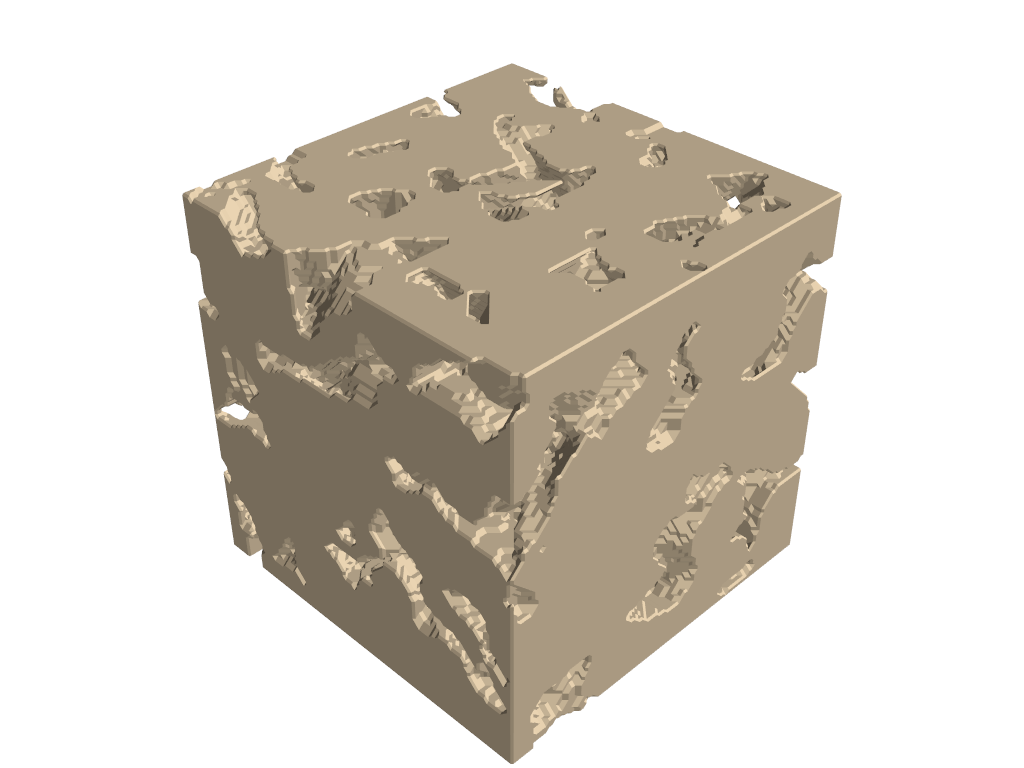

In [6]:
# Close the boundaries of the image:
sandstone_pad = np.pad(sandstone_subset, ((1, 1), (1, 1), (1, 1)), mode='constant', constant_values=0)

# Visualize
plot_sample(sandstone_pad)

### Medial Axis Extraction
#### 1. Bead Pack

In [1]:
# Get medial axis
beadpack_medial_axis = skimage.morphology.skeletonize(bead_pack_subset)

# Plot
mesh_kwargs = {'line_width':2, 'style':'wireframe', 'color': 'r'}
plot_sample(beadpack_medial_axis, mesh_kwargs)

NameError: name 'skimage' is not defined

#### Make it Fancier:

C:\Users\masha\anaconda3\Lib\site-packages\pyvista\jupyter\notebook.py:34: UserWarning: Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (C:\Users\masha\anaconda3\Lib\site-packages\trame\widgets\__init__.py)

Falling back to a static output.
  warnings.warn(


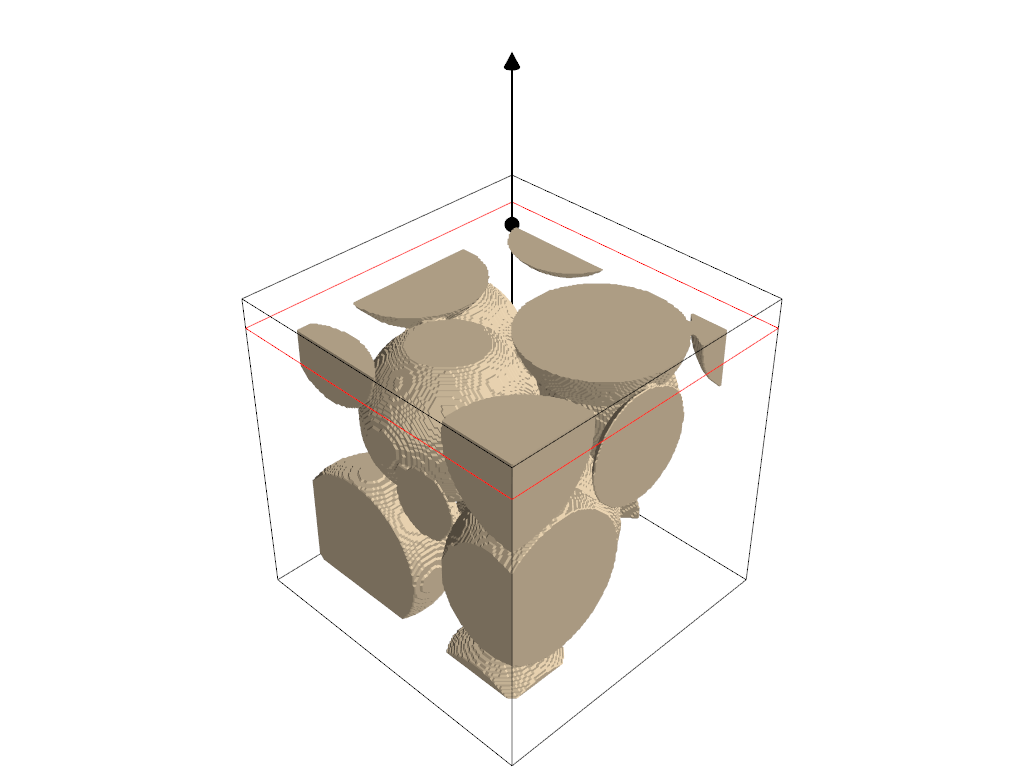

In [9]:
plotter = pv.Plotter(notebook=True, lighting='three lights')

pv_bead_pack_medial_axis = pv.wrap(beadpack_medial_axis)
contours_ma = pv_bead_pack_medial_axis.contour(isosurfaces=[0.5])
plotter.add_mesh(contours_ma , color='r', style='wireframe', line_width=3)

pv_bead_pack_sample = pv.wrap(bead_pack_pad)
contours_sample = pv_bead_pack_sample.contour(isosurfaces=[0.5])


def my_plane_func(normal, origin):
    sliced = contours_sample.slice(normal=normal, origin=origin)
    plotter.add_mesh(contours_sample.clip_closed_surface(normal='-z', origin=origin),
                name='arrows',color = (200 / 255, 181 / 255, 152 / 255))


plotter.add_plane_widget(my_plane_func, normal='z',origin=[0, 0, beadpack_medial_axis.shape[2]])
plotter.show()

### 2. Sandstone

In [71]:
# Get medial axis
sandstone_medial_axis = skimage.morphology.skeletonize(sandstone_subset)

plotter = pv.Plotter(notebook=True, lighting='three lights')

pv_sandstone_medial_axis = pv.wrap(sandstone_medial_axis)
contours_ma = pv_sandstone_medial_axis.contour(isosurfaces=[0.5])
plotter.add_mesh(contours_ma , color='r', style='wireframe', line_width=2)

pv_sandstone_sample = pv.wrap(sandstone_pad)
contours_sample = pv_sandstone_sample.contour(isosurfaces=[0.5])


def my_plane_func(normal, origin):
    sliced = contours_sample.slice(normal=normal, origin=origin)
    plotter.add_mesh(contours_sample.clip_closed_surface(normal='-z', origin=origin),
                name='arrows',color = (200 / 255, 181 / 255, 152 / 255))


plotter.add_plane_widget(my_plane_func, normal='z',origin=[0, 0, sandstone_medial_axis.shape[2]])
plotter.show()

Widget(value='<iframe src="http://localhost:39145/index.html?ui=P_0x7ff50d6e6850_56&reconnect=auto" class="pyv…